In [1]:
%matplotlib widget
#importing libraries
from src.MFE import *
from src.MyUlamGalerkin import *
from src.LeichtNewman import *
from src.MST import *
from src.helper import *
from src.visulization import *
from src.SnapCluster import SnapCluster
from src.UlamGalerkin import UlamGalerkin
from src.Dijkstras import *

import time
import numpy as np
import math 
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.widgets import Button, Slider
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FFMpegWriter
from pathlib import Path
from sklearn.cluster import KMeans
import networkx as nx
from collections import Counter
import matplotlib.ticker as mticker
import sys
from joblib import Parallel, delayed
#%load_ext autoreload
#%autoreload 2
#%reload_ext autoreload
np.set_printoptions(suppress=True) # to avoid scientific notation in numpy printing



In [2]:
#Plot Settings


plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.family']='serif'

Time: 500.0s


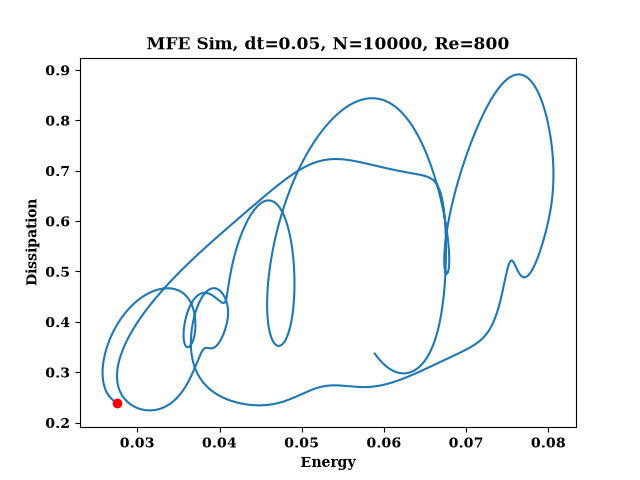

In [3]:
#Start the MFE sequence generation


dt,N,istart =0.05,20000,10000      # time-step and number of trajectory points
Re=800
Lx,Lz=1.75*np.pi,1.2*np.pi
D,E,a = MFE_Sequence(dt,N,istart,Re,Lx,Lz,a0=[0,0,0.187387,0.040112,0.047047,0,0,0.013188,0])   # generate data sequence 
#D2,E2,a2 = MFE_Sequence(dt,N,istart,Re,Lx,Lz,a0=[0.0000000000001,0,0.187387,0.040112,0.047047,0,0,0.013188,0])   # generate data sequence 
#t=(np.arange(len(D))+1)*dt
DE = np.vstack((D,E)).T
#DE2 = np.vstack((D2,E2)).T
DE0=DE.copy()
caseName=""
Case=create_case_folder(dt,N-istart,Re,Lx,Lz)  
Case = os.path.join(Case, caseName)  

figo, axo = plt.subplots()

t=0
axo.plot(DE[:, 1], DE[:, 0])
#axo.plot(DE2[:, 1], DE2[:, 0])
axo.scatter(DE[-1, 1], DE[-1, 0],c="red",zorder=10)
#axo.scatter(DE2[-1, 1], DE2[-1, 0],c="green",zorder=10)

axo.set_title(f'MFE Sim, dt={dt}, N={N-istart}, Re={Re}')
path = Path(os.path.join(Case, f"DE_N={N-istart}_dt={dt}_Re={Re}.png"))
axo.set_xlabel("Energy")
axo.set_ylabel("Dissipation")
#axo.set_xlim(0,0.3)
#axo.set_ylim(0,3)
#axo.set_facecolor("#EAEBF4")
figo.savefig(path)  
idx = [
    np.argmin(DE[:, 0]),
    np.argmax(DE[:, 0]),
    np.argmin(DE[:, 1]),
    np.argmax(DE[:, 1])
]

DE = DE[idx]
a = a[idx]
print(F"Time: {dt*(N-istart)}s")

In [54]:
Disctrize_box_size=100 #Chose the box size for Ulam-Galerkin
A= SnapCluster(DE,Disctrize_box_size,len(DE))
M=A.P
box_idx_list=list(A.Box.keys())

sample=5000000


Time for Ulam-Galerkin Disctrization:0.20190369998454116
Number of boxes: 5044


In [55]:

def a0_calc(B,chose_box,a):
    chose_box_list=list(B.Box.values())
    chose_a=a[chose_box_list[chose_box]]
    
    if len(chose_a) < 5:
        idx=np.random.randint(len(chose_a))
        a0 = chose_a[idx] * (1 + np.random.uniform(-1e-6, 1e-6))
    else:
        
        weights = np.random.rand(2)
        weights /= weights.sum()
        idx=np.random.randint(len(chose_a))
        idx2=np.random.randint(len(chose_a))
        a0=weights[0]*chose_a[idx]+weights[1]*chose_a[idx2]
        '''
    #print(chose_a)
        weights = np.random.rand(len(chose_a))
        weights /= weights.sum()
        a0 = np.tensordot(weights, chose_a, axes=1)
        '''
    #print(a0)
    

    return a0

A=SnapCluster(DE,Disctrize_box_size,sim_time=N-istart,sample_time=sample)
j=len(A.Box)
#while min(M.sum(axis=0))<2:
for s in range(1000):
    
    j-=1#int(1+len(A.Box)/10)
    if j<=0:#len(A.Box):
        j=len(A.Box)
    chose_box=np.argmin(M.sum(axis=0))
    #if M.sum(axis=0)[chose_box]>1000:
        #continue
    A= SnapCluster(DE,Disctrize_box_size,sim_time=N-istart,sample_time=sample)
    box_idx_list=list(A.Box.keys())
    M=A.P
    filled_boxes=M.sum(axis=0)>0
    print(M.sum(axis=0))
    print(f"{j},Number of points= {len(DE)}")
    #for i in range(1):
    a0_supp=a0_calc(A,chose_box,a)
    D_supp,E_supp,a_supp = MFE_Sequence(dt,sample,1,Re,Lx,Lz,a0=a0_supp)
    DE_supp = np.vstack((D_supp,E_supp)).T
    
    x=DE.copy()      
    mini = np.min(x, axis=0)        #Extract minimum value of all physical variables 
    maxi = np.max(x, axis=0)        #Extract maximum value of all physical variables
    delta=(maxi+10e-12-mini)/Disctrize_box_size            #Discretize the state space into cells
    idx = np.floor((DE_supp - mini) / delta).astype(int)
    idx_unique,re_index=np.unique(idx,axis=0,return_index=True) 

    mask_res1=np.array([i in re_index for i in range(len(idx))])
    print(f"one point mask: {np.sum(mask_res1)}")
    invalid = set(map(tuple, np.array(box_idx_list)[filled_boxes]))
    
    mask_res2 = np.array([tuple(row) not in invalid for row in idx])
    print(f"filled boxes mask: {np.sum(mask_res2)}")

    print(np.sum(mask_res1&mask_res2))
    #print(mask_res1[0])
    #if np.all(mask_res1)!=True:
        #  continue
    
    DE_supp=DE_supp[mask_res1 & mask_res2]
    a_supp=a_supp[mask_res1 & mask_res2]
    DE=np.vstack((DE,DE_supp))
    a=np.vstack((a,a_supp))

A=SnapCluster(DE,Disctrize_box_size,sim_time=N-istart,sample_time=sample)

Time for Ulam-Galerkin Disctrization:0.191730299993651
Number of boxes: 5044
Time for Ulam-Galerkin Disctrization:0.20635569997830316
Number of boxes: 5044
[34 41 41 ...  3  1  6]
5043,Number of points= 72864
one point mask: 1695
filled boxes mask: 0
0
Time for Ulam-Galerkin Disctrization:0.19492469998658635
Number of boxes: 5044
[34 41 41 ...  3  1  6]
5042,Number of points= 72864
one point mask: 2543
filled boxes mask: 78
13
Time for Ulam-Galerkin Disctrization:0.1952379000140354
Number of boxes: 5057
[34 41 41 ...  3  1  6]
5041,Number of points= 72877
one point mask: 1846
filled boxes mask: 14
5
Time for Ulam-Galerkin Disctrization:0.1820325999869965
Number of boxes: 5062
[34 41 41 ...  3  1  6]
5040,Number of points= 72882
one point mask: 1745
filled boxes mask: 340
17
Time for Ulam-Galerkin Disctrization:0.17880199998035096
Number of boxes: 5079
[34 41 41 ...  3  1  6]
5039,Number of points= 72899
one point mask: 1694
filled boxes mask: 100
13
Time for Ulam-Galerkin Disctrization

KeyboardInterrupt: 

Text(0, 0.5, 'Dissipation')

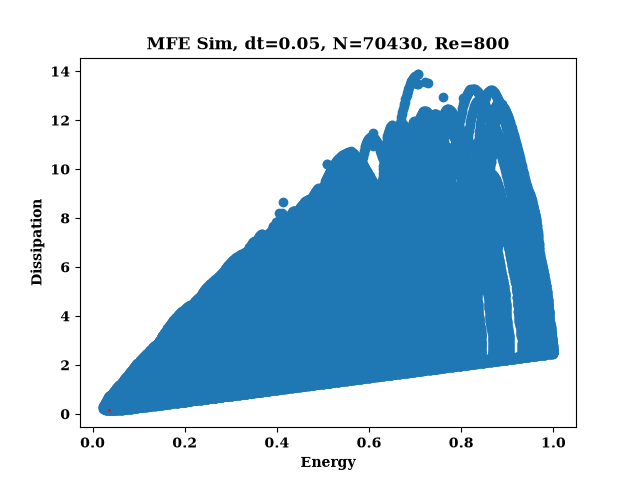

In [50]:
figo, axo = plt.subplots()
axo.scatter(DE[:, 1], DE[:, 0])
axo.scatter(DE[t, 1], DE[t, 0],c="red",zorder=10,s=0.5)
axo.set_title(f'MFE Sim, dt={dt}, N={len(DE)}, Re={Re}')
axo.set_xlabel("Energy")
axo.set_ylabel("Dissipation")

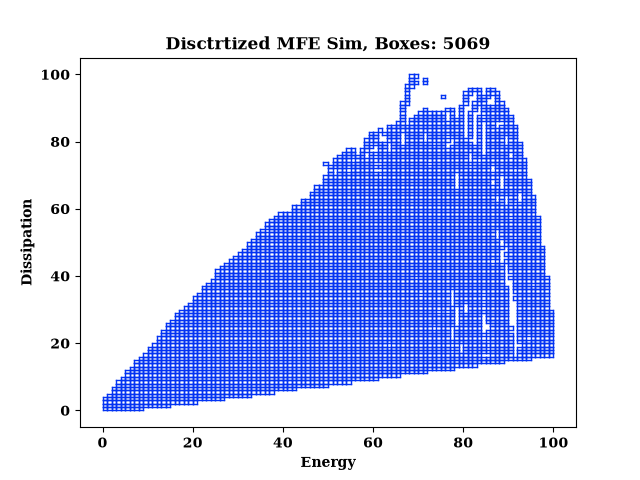

In [62]:
plot_disctrized_phase_space(DE,100)

In [63]:
print(len(DE))
print(len(a))

145904
145904


In [ ]:

sample=5000
for i in range(len(DE)):
    a0_supp=a[i]
    D_supp,E_supp,a_supp = MFE_Sequence(dt,sample,0,Re,Lx,Lz,a0=a0_supp)
    DE_supp = np.vstack((D_supp,E_supp)).T    
    DE=np.vstack((DE,DE_supp))
    a=np.vstack((a,a_supp))
    DE=DE[2:]
    a=a[2:]
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [75]:
A=SnapCluster(DE,100,sim_time=N-istart,sample_time=sample)


Time for Ulam-Galerkin Disctrization:0.39432969997869805
Number of boxes: 5069


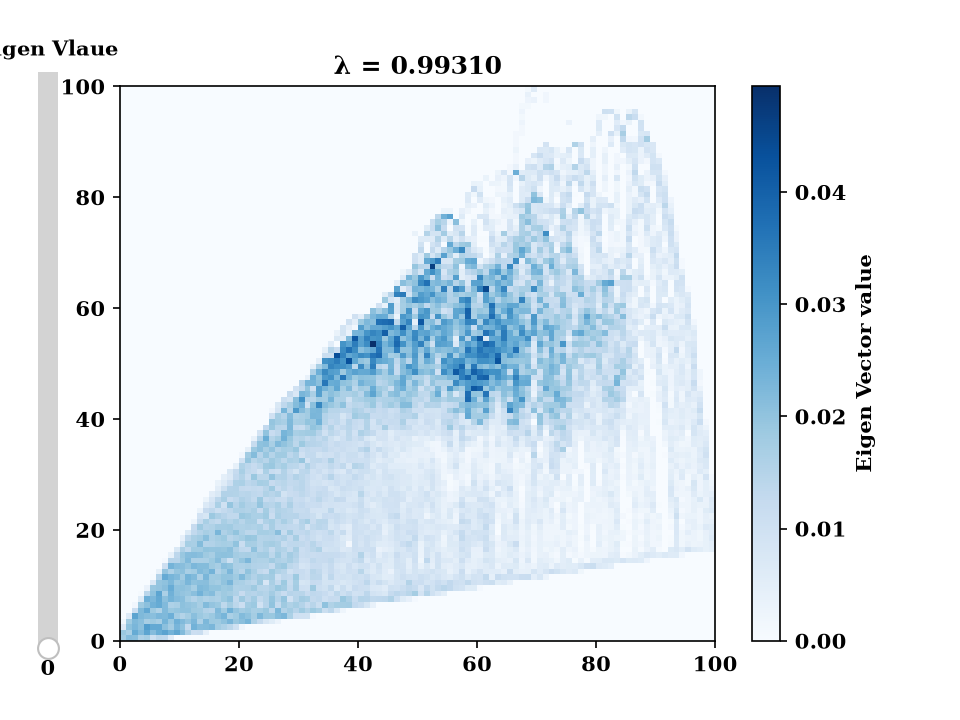

In [81]:
cluster_k=0
eigen_num=1
P,box_idx=box_cluster_transition_matrix(A.CPT,k=cluster_k,sim_time=N-istart,sample_time=sample)
sorted_bx_clusters = np.array(list(dict(sorted(box_idx.items(), key=lambda item: item[0])).values()))
#P=cluster_transition_matrix(A.CPT,k=cluster_k)

Nd=Disctrize_box_size
x=DE.copy()      
mini = np.min(x, axis=0)        #Extract minimum value of all physical variables 
maxi = np.max(x, axis=0)        #Extract maximum value of all physical variables
delta=(maxi+10e-12-mini)/Nd            #Discretize the state space into cells
idx = np.floor((x - mini) / delta).astype(int)

grid = np.zeros((Nd, Nd))
filled_grid=[]
for i in range(len(idx)):
    E_idx = idx[i, 1]
    d_idx = idx[i, 0]
    grid[d_idx,E_idx] += 1

for i in range(Disctrize_box_size):
    for j in range(Disctrize_box_size):
        if grid[i,j]>0:
            filled_grid.append([i,j])

eigs,vec=np.linalg.eig(P)
idx=np.argsort(-np.abs(eigs))
eigs=eigs[idx]
vec=vec[:,idx]      

grid_eigenvector_value = np.zeros((Nd, Nd))
for i,value in enumerate(np.abs(vec[:,eigen_num])):
    idx=np.where(sorted_bx_clusters==i)[0]
    for s in idx:
        grid_idx=tuple(filled_grid[s])
        grid_eigenvector_value[grid_idx]=value
mask=np.where(grid_eigenvector_value>0)
log_grid_eigenvector_value=np.full_like(grid_eigenvector_value,-np.inf)
log_grid_eigenvector_value[mask]=np.log(grid_eigenvector_value[mask])


###### Plot ######
plt.close("all")
fig, ax = plt.subplots(dpi=150)
mesh = ax.pcolormesh(grid_eigenvector_value, cmap="Blues")#,norm=mcolors.Normalize(vmin=0, vmax=0.1))
cbar=fig.colorbar(mesh, ax=ax)
cbar.set_label("Eigen Vector value")
ax.set_title(f"λ = {np.abs(eigs[eigen_num]):.5f}")

###### Slider ######
discrete_values = [i for i in range(len(P))]
ax_slider = plt.axes([0.03, 0.1, 0.04, 0.8])
slider = Slider(
    ax_slider, 'Eigen Vlaue',
    min(discrete_values), max(discrete_values),
    valinit=discrete_values[0],
    valstep=discrete_values,orientation='vertical'
)


def update(val):
    eigen_num = slider.val 
    grid_eigenvector_value = np.zeros((Nd, Nd))
    for i,value in enumerate(np.abs(vec[:,eigen_num])):
        idx=np.where(sorted_bx_clusters==i)[0]
        for s in idx:
            grid_idx=tuple(filled_grid[s])
            grid_eigenvector_value[grid_idx]=value
    mask=np.where(grid_eigenvector_value>0)
    log_grid_eigenvector_value=np.full_like(grid_eigenvector_value,-np.inf)
    log_grid_eigenvector_value[mask]=np.log(grid_eigenvector_value[mask])

    mesh.set_array(grid_eigenvector_value)
    ax.set_title(f"λ = {np.abs(eigs[eigen_num]):.5f}")
    fig.canvas.draw_idle()
slider.on_changed(update)
plt.show()
